In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [53]:
acct = pd.read_csv(r"C:\Users\Ifeoluwa\OneDrive\Documents\Finlora\data\processed\finlora_accounts_cleaned.csv")
txn = pd.read_csv(r"C:\Users\Ifeoluwa\OneDrive\Documents\Finlora\data\processed\finlora_transactions_cleaned.csv")

In [54]:
print(txn.columns.tolist())

['transaction_id', 'account_id', 'account_type', 'kyc_tier', 'timestamp', 'day_of_week', 'hour_of_day', 'description', 'merchant_name', 'merchant_category', 'channel', 'amount', 'currency', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'transaction_country', 'home_country', 'is_cross_border', 'device_id', 'is_new_device', 'account_age_days', 'status', 'is_fraud']


In [55]:
txn['timestamp'] = pd.to_datetime(txn['timestamp'], format='%Y-%m-%d %H:%M:%S')

In [56]:
txn.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   transaction_id              126000 non-null  str           
 1   account_id                  126000 non-null  str           
 2   account_type                126000 non-null  str           
 3   kyc_tier                    126000 non-null  str           
 4   timestamp                   126000 non-null  datetime64[us]
 5   day_of_week                 126000 non-null  str           
 6   hour_of_day                 126000 non-null  int64         
 7   description                 126000 non-null  str           
 8   merchant_name               126000 non-null  str           
 9   merchant_category           126000 non-null  str           
 10  channel                     126000 non-null  str           
 11  amount                      126000 non-null  float

In [57]:
merge = pd.merge(txn, acct, how='left', on='account_id')

In [58]:
merge.head()

,transaction_id,account_id,account_type_x,kyc_tier_x,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,account_age_days,status,is_fraud,account_holder_name,account_type_y,home_country_y,currency_y,kyc_tier_y,account_created_date,personal_spend_baseline_usd
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,...,903,Completed,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,...,969,Declined,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,...,970,Completed,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,...,974,Completed,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,...,1035,Declined,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23


In [59]:
merge.shape

(126000, 31)

In [60]:
merge = merge.drop(columns=['account_type_y', 'kyc_tier_y'])

In [61]:
print(merge.columns.tolist())

['transaction_id', 'account_id', 'account_type_x', 'kyc_tier_x', 'timestamp', 'day_of_week', 'hour_of_day', 'description', 'merchant_name', 'merchant_category', 'channel', 'amount', 'currency_x', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'transaction_country', 'home_country_x', 'is_cross_border', 'device_id', 'is_new_device', 'account_age_days', 'status', 'is_fraud', 'account_holder_name', 'home_country_y', 'currency_y', 'account_created_date', 'personal_spend_baseline_usd']


In [62]:
merge = merge.drop(columns=['currency_y', 'home_country_y'])

In [63]:
merge = merge.rename(columns={
    'account_type_x': 'account_type', 'kyc_tier_x': 'kyc_tier', 
    'currency_x': 'currency', 'home_country_x': 'home_country'}, 
    )

In [66]:
merge.shape

(126000, 27)

In [67]:
print(merge.columns.tolist())

['transaction_id', 'account_id', 'account_type', 'kyc_tier', 'timestamp', 'day_of_week', 'hour_of_day', 'description', 'merchant_name', 'merchant_category', 'channel', 'amount', 'currency', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'transaction_country', 'home_country', 'is_cross_border', 'device_id', 'is_new_device', 'account_age_days', 'status', 'is_fraud', 'account_holder_name', 'account_created_date', 'personal_spend_baseline_usd']


In [68]:
merge['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.973397
1    0.026603
Name: proportion, dtype: float64

In [69]:
merge['amount'].describe()

count    1.260000e+05
mean     7.964918e+05
std      4.054387e+06
min     -1.834602e+06
25%      6.310500e+01
50%      5.942240e+03
75%      1.208470e+05
max      2.691614e+08
Name: amount, dtype: float64

In [ ]:
merge[merge['amount'] < 0].shape[0]

291

### Negative amounts (n=291, likely refunds/reversals) show a fraud rate of 2.06%, slightly below the 2.66% overall baseline — not a meaningful fraud signal on its own.###

In [74]:
merge[merge['amount'] < 0]['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.979381
1    0.020619
Name: proportion, dtype: float64

In [75]:
merge['amount_to_avg_ratio'].describe()

count    126000.000000
mean          7.921400
std         153.566706
min           0.000000
25%           0.250000
50%           0.980000
75%           1.830000
max       31762.690000
Name: amount_to_avg_ratio, dtype: float64

In [76]:
merge['transaction_velocity_1h'].describe()

count    126000.000000
mean          0.011429
std           0.110323
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: transaction_velocity_1h, dtype: float64

In [77]:
merge['account_age_days'].describe()

count    126000.000000
mean        354.721992
std         331.327033
min           0.000000
25%          35.000000
50%         289.000000
75%         577.000000
max        1682.000000
Name: account_age_days, dtype: float64

In [78]:
merge['channel'].value_counts()

channel
Mobile App          41615
Web Dashboard       31330
Card Not Present    17422
Card Present        15080
API/Integration     13083
USSD                 7470
Name: count, dtype: int64

In [79]:
merge['merchant_category'].value_counts()

merchant_category
Payroll Transfer     17117
Retail               13742
Groceries            13650
Utilities            12444
Subscription/SaaS    12006
P2P Transfer         10715
Restaurants           8416
Wire Transfer         7639
Travel                7416
Electronics           6173
ATM Withdrawal        5129
Insurance             4528
Healthcare            4382
Crypto Exchange       1692
Gambling/Gaming        951
Name: count, dtype: int64

In [80]:
merge['kyc_tier'].value_counts()


kyc_tier
Tier2_Verified    64094
Tier3_Enhanced    39094
Tier1_Basic       22812
Name: count, dtype: int64

In [81]:
merge['account_type'].value_counts()

account_type
Individual    82112
Business      43888
Name: count, dtype: int64

In [82]:
merge['status'].value_counts()

status
Completed    116703
Declined       5629
Reversed       3668
Name: count, dtype: int64

In [92]:
merge.groupby('is_fraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,7.542609e+05,3.925729e+06,-1834602.45,60.9950,5511.62,1.123308e+05,2.691614e+08
1,3352.0,2.341700e+06,7.181019e+06,-199857.63,686.4125,107175.72,1.532317e+06,1.887415e+08


In [84]:
merge.groupby('is_fraud')['amount_to_avg_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,3.980504,61.461151,0.00,0.24,0.95,1.730,11044.22
1,3352.0,152.116811,852.700246,0.01,0.63,6.04,56.525,31762.69


In [85]:
merge.groupby('is_fraud')['transaction_velocity_1h'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,0.000905,0.031655,0.0,0.0,0.0,0.0,2.0
1,3352.0,0.396480,0.518266,0.0,0.0,0.0,1.0,3.0


In [86]:
merge.groupby('is_fraud')['account_age_days'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,355.442657,331.696733,0.0,36.0,289.0,578.0,1677.0
1,3352.0,328.353222,316.424461,0.0,0.0,276.0,524.5,1682.0


In [87]:
merge.groupby('channel')['is_fraud'].mean()

channel
API/Integration     0.036460
Card Not Present    0.023419
Card Present        0.022414
Mobile App          0.025111
USSD                0.021151
Web Dashboard       0.029556
Name: is_fraud, dtype: float64

In [88]:
merge.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)


merchant_category
Wire Transfer        0.075795
Payroll Transfer     0.055909
Crypto Exchange      0.052009
Travel               0.027913
P2P Transfer         0.025385
Insurance            0.023410
Electronics          0.020735
Gambling/Gaming      0.017876
Utilities            0.017760
Healthcare           0.015746
Retail               0.014772
ATM Withdrawal       0.014428
Subscription/SaaS    0.013743
Groceries            0.012601
Restaurants          0.011169
Name: is_fraud, dtype: float64

In [89]:
merge.groupby('kyc_tier')['is_fraud'].mean()

kyc_tier
Tier1_Basic       0.032527
Tier2_Verified    0.027304
Tier3_Enhanced    0.021998
Name: is_fraud, dtype: float64

In [90]:
merge.groupby('account_type')['is_fraud'].mean()

account_type
Business      0.03935
Individual    0.01979
Name: is_fraud, dtype: float64

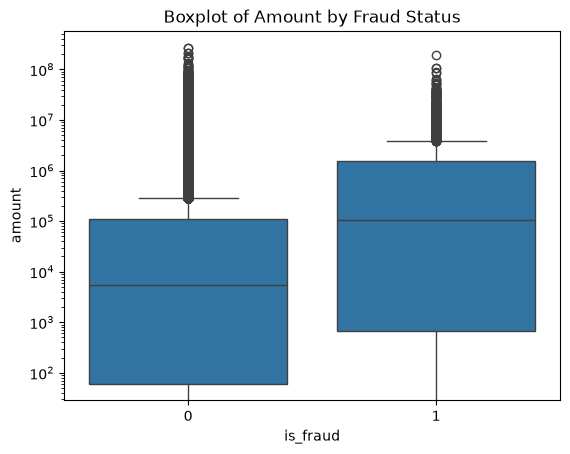

In [95]:
sns.boxplot(data=merge, x='is_fraud', y='amount')
plt.yscale('log')
plt.title('Boxplot of Amount by Fraud Status')
plt.show()

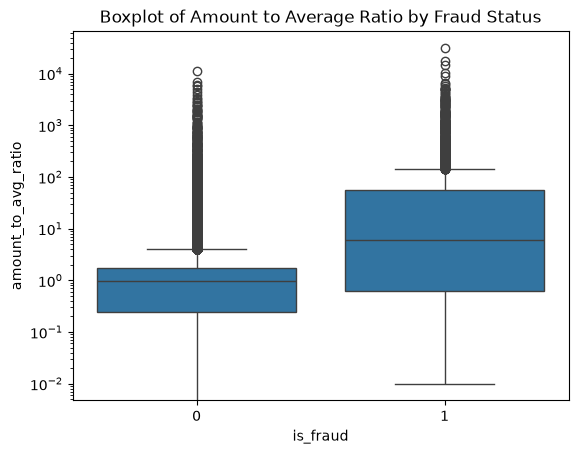

In [97]:
sns.boxplot(data=merge, x='is_fraud', y='amount_to_avg_ratio')
plt.yscale('log')
plt.title('Boxplot of Amount to Average Ratio by Fraud Status')
plt.show()

In [98]:
merge.corr(numeric_only=True)

,hour_of_day,amount,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,is_cross_border,account_age_days,is_fraud,personal_spend_baseline_usd
hour_of_day,1.000000,-0.007345,-0.004077,-0.005624,0.010686,0.002224,-0.002936,0.003477,0.001252
amount,-0.007345,1.000000,0.226321,0.527842,0.018889,0.004647,0.004093,0.063006,0.328820
amount_to_avg_ratio,-0.004077,0.226321,1.000000,-0.010459,-0.004399,-0.001411,0.007634,0.155231,0.069049
avg_transaction_amount_30d,-0.005624,0.527842,-0.010459,1.000000,0.023282,0.001579,0.003296,-0.001848,0.387650
transaction_velocity_1h,0.010686,0.018889,-0.004399,0.023282,1.000000,-0.008226,-0.007592,0.577002,0.013617
is_cross_border,0.002224,0.004647,-0.001411,0.001579,-0.008226,1.000000,-0.001109,0.006764,0.004652
account_age_days,-0.002936,0.004093,0.007634,0.003296,-0.007592,-0.001109,1.000000,-0.013157,0.024612
is_fraud,0.003477,0.063006,0.155231,-0.001848,0.577002,0.006764,-0.013157,1.000000,0.024793
personal_spend_baseline_usd,0.001252,0.328820,0.069049,0.387650,0.013617,0.004652,0.024612,0.024793,1.000000
